In [2]:
import numpy as np 
import pandas as pd 

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR

In [3]:
df=pd.read_csv("C:/Users/A/OneDrive/Desktop/Cleaned_HR_Data_Analysis.csv")
df

,Employee ID,StartDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,DepartmentType,Division,...,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Training Cost,Age
0,3427,20-Sep-19,Production Technician I,CCDR,Active,Contract,Zone C,Temporary,Production,Finance & Accounting,...,1,2,3,15-Jul-23,Leadership Development,Internal,Failed,2,606.11,50
1,3428,11-Feb-23,Production Technician I,EW,Active,Contract,Zone A,Part-Time,Production,Aerial,...,2,1,5,12-Sep-22,Customer Service,External,Incomplete,4,673.02,58
2,3429,10-Dec-18,Area Sales Manager,PL,Active,Full-Time,Zone B,Part-Time,Sales,General - Sga,...,1,2,1,13-Aug-22,Leadership Development,External,Failed,2,413.28,27
3,3430,21-Jun-21,Area Sales Manager,CCDR,Active,Contract,Zone A,Full-Time,Sales,Finance & Accounting,...,5,5,4,15-Dec-22,Project Management,External,Completed,3,663.78,23
4,3431,29-Jun-19,Area Sales Manager,TNS,Active,Contract,Zone A,Temporary,Sales,General - Con,...,2,5,3,13-Jul-23,Technical Skills,External,Failed,5,399.03,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2840,3421,09-May-22,Production Technician I,PL,Active,Part-Time,Zone A,Part-Time,Production,Wireless,...,5,4,2,22-Jan-23,Customer Service,External,Passed,1,786.71,63
2841,3423,28-Dec-20,Production Technician I,SVG,Active,Part-Time,Zone A,Full-Time,Production,Engineers,...,4,5,3,14-Oct-22,Technical Skills,External,Completed,1,439.65,19
2842,3424,09-Dec-20,Production Technician I,TNS,Terminated,Contract,Zone B,Temporary,Production,Wireline Construction,...,2,4,5,18-Aug-22,Project Management,Internal,Completed,5,981.13,23
2843,3425,28-May-19,Production Technician I,WBL,Terminated,Contract,Zone B,Full-Time,Production,Aerial,...,5,2,3,19-May-23,Technical Skills,External,Completed,3,184.27,65


In [3]:
df.isnull().sum()

Employee ID                   0
StartDate                     0
Title                         0
BusinessUnit                  0
EmployeeStatus                0
EmployeeType                  0
PayZone                       0
EmployeeClassificationType    0
DepartmentType                0
Division                      0
DOB                           0
State                         0
GenderCode                    0
RaceDesc                      0
MaritalDesc                   0
Performance Score             0
Current Employee Rating       0
Survey Date                   0
Engagement Score              0
Satisfaction Score            0
Work-Life Balance Score       0
Training Date                 0
Training Program Name         0
Training Type                 0
Training Outcome              0
Training Duration(Days)       0
Training Cost                 0
Age                           0
dtype: int64

In [5]:
df.drop_duplicates()

,Employee ID,StartDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,DepartmentType,Division,...,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Training Cost,Age
0,3427,20-Sep-19,Production Technician I,CCDR,Active,Contract,Zone C,Temporary,Production,Finance & Accounting,...,1,2,3,15-Jul-23,Leadership Development,Internal,Failed,2,606.11,50
1,3428,11-Feb-23,Production Technician I,EW,Active,Contract,Zone A,Part-Time,Production,Aerial,...,2,1,5,12-Sep-22,Customer Service,External,Incomplete,4,673.02,58
2,3429,10-Dec-18,Area Sales Manager,PL,Active,Full-Time,Zone B,Part-Time,Sales,General - Sga,...,1,2,1,13-Aug-22,Leadership Development,External,Failed,2,413.28,27
3,3430,21-Jun-21,Area Sales Manager,CCDR,Active,Contract,Zone A,Full-Time,Sales,Finance & Accounting,...,5,5,4,15-Dec-22,Project Management,External,Completed,3,663.78,23
4,3431,29-Jun-19,Area Sales Manager,TNS,Active,Contract,Zone A,Temporary,Sales,General - Con,...,2,5,3,13-Jul-23,Technical Skills,External,Failed,5,399.03,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2840,3421,09-May-22,Production Technician I,PL,Active,Part-Time,Zone A,Part-Time,Production,Wireless,...,5,4,2,22-Jan-23,Customer Service,External,Passed,1,786.71,63
2841,3423,28-Dec-20,Production Technician I,SVG,Active,Part-Time,Zone A,Full-Time,Production,Engineers,...,4,5,3,14-Oct-22,Technical Skills,External,Completed,1,439.65,19
2842,3424,09-Dec-20,Production Technician I,TNS,Terminated,Contract,Zone B,Temporary,Production,Wireline Construction,...,2,4,5,18-Aug-22,Project Management,Internal,Completed,5,981.13,23
2843,3425,28-May-19,Production Technician I,WBL,Terminated,Contract,Zone B,Full-Time,Production,Aerial,...,5,2,3,19-May-23,Technical Skills,External,Completed,3,184.27,65


In [9]:
#Check categorical columns:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
categorical_columns,numeric_columns

(['StartDate',
  'Title',
  'BusinessUnit',
  'EmployeeStatus',
  'EmployeeType',
  'PayZone',
  'EmployeeClassificationType',
  'DepartmentType',
  'Division',
  'DOB',
  'State',
  'GenderCode',
  'RaceDesc',
  'MaritalDesc',
  'Performance Score',
  'Survey Date',
  'Training Date',
  'Training Program Name',
  'Training Type',
  'Training Outcome'],
 ['Employee ID',
  'Current Employee Rating',
  'Engagement Score',
  'Satisfaction Score',
  'Work-Life Balance Score',
  'Training Duration(Days)',
  'Training Cost',
  'Age'])

In [11]:
df.shape

(2845, 28)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2845 entries, 0 to 2844
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee ID                 2845 non-null   int64  
 1   StartDate                   2845 non-null   object 
 2   Title                       2845 non-null   object 
 3   BusinessUnit                2845 non-null   object 
 4   EmployeeStatus              2845 non-null   object 
 5   EmployeeType                2845 non-null   object 
 6   PayZone                     2845 non-null   object 
 7   EmployeeClassificationType  2845 non-null   object 
 8   DepartmentType              2845 non-null   object 
 9   Division                    2845 non-null   object 
 10  DOB                         2845 non-null   object 
 11  State                       2845 non-null   object 
 12  GenderCode                  2845 non-null   object 
 13  RaceDesc                    2845 

In [13]:
df.describe()

,Employee ID,Current Employee Rating,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Duration(Days),Training Cost,Age
count,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000
mean,2470.591916,2.974692,2.941652,3.028471,2.989104,2.973989,559.278956,49.448506
std,859.450107,1.012610,1.435230,1.410067,1.408816,1.419682,263.333611,17.689179
min,1001.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.040000,17.000000
25%,1736.000000,2.000000,2.000000,2.000000,2.000000,2.000000,328.060000,34.000000
50%,2456.000000,3.000000,3.000000,3.000000,3.000000,3.000000,571.810000,49.000000
75%,3197.000000,3.000000,4.000000,4.000000,4.000000,4.000000,788.330000,65.000000
max,4000.000000,5.000000,5.000000,5.000000,5.000000,5.000000,999.970000,82.000000


In [14]:
df.drop(["Employee ID","StartDate","DOB","Survey Date","Training Date"], axis=1)

,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,DepartmentType,Division,State,GenderCode,...,Current Employee Rating,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Training Cost,Age
0,Production Technician I,CCDR,Active,Contract,Zone C,Temporary,Production,Finance & Accounting,MA,Female,...,4,1,2,3,Leadership Development,Internal,Failed,2,606.11,50
1,Production Technician I,EW,Active,Contract,Zone A,Part-Time,Production,Aerial,MA,Male,...,3,2,1,5,Customer Service,External,Incomplete,4,673.02,58
2,Area Sales Manager,PL,Active,Full-Time,Zone B,Part-Time,Sales,General - Sga,MA,Male,...,4,1,2,1,Leadership Development,External,Failed,2,413.28,27
3,Area Sales Manager,CCDR,Active,Contract,Zone A,Full-Time,Sales,Finance & Accounting,ND,Male,...,2,5,5,4,Project Management,External,Completed,3,663.78,23
4,Area Sales Manager,TNS,Active,Contract,Zone A,Temporary,Sales,General - Con,FL,Female,...,3,2,5,3,Technical Skills,External,Failed,5,399.03,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2840,Production Technician I,PL,Active,Part-Time,Zone A,Part-Time,Production,Wireless,MA,Female,...,1,5,4,2,Customer Service,External,Passed,1,786.71,63
2841,Production Technician I,SVG,Active,Part-Time,Zone A,Full-Time,Production,Engineers,MA,Male,...,3,4,5,3,Technical Skills,External,Completed,1,439.65,19
2842,Production Technician I,TNS,Terminated,Contract,Zone B,Temporary,Production,Wireline Construction,MA,Male,...,2,2,4,5,Project Management,Internal,Completed,5,981.13,23
2843,Production Technician I,WBL,Terminated,Contract,Zone B,Full-Time,Production,Aerial,MA,Female,...,2,5,2,3,Technical Skills,External,Completed,3,184.27,65


In [16]:
#check how many unique recored
df['Training Program Name'].unique()

array(['Leadership Development', 'Customer Service', 'Project Management',
       'Technical Skills', 'Communication Skills'], dtype=object)

In [17]:
df['Training Type'].unique()

array(['Internal', 'External'], dtype=object)

In [18]:
df['Training Outcome'].unique()

array(['Failed', 'Incomplete', 'Completed', 'Passed'], dtype=object)

In [19]:
#Label encoding:

In [20]:
from sklearn.preprocessing import LabelEncoder

In [21]:
le=LabelEncoder()
le

LabelEncoder()

In [22]:
df['gender']=le.fit_transform(df['GenderCode'])
df['gender']

0       0
1       1
2       1
3       1
4       0
       ..
2840    0
2841    1
2842    1
2843    0
2844    0
Name: gender, Length: 2845, dtype: int64

In [23]:
df['TrainingType_Encoded']=le.fit_transform(df['Training Type'])
df['TrainingType_Encoded']

0       1
1       0
2       0
3       0
4       0
       ..
2840    0
2841    0
2842    1
2843    0
2844    1
Name: TrainingType_Encoded, Length: 2845, dtype: int64

In [24]:
df['EmployeeStatus_Encoded'] = le.fit_transform(df['EmployeeStatus'])
df['TrainingOutcome_Encoded'] = le.fit_transform(df['Training Outcome'])
df['PerformanceScore_Encoded'] = le.fit_transform(df['Performance Score'])

In [25]:
prog_dummies = pd.get_dummies(df['Training Program Name'], prefix='Prog')
df= pd.concat([df, prog_dummies], axis=1)

In [27]:
zone_dummies = pd.get_dummies(df['PayZone'], prefix='Zone')
df = pd.concat([df, zone_dummies], axis=1)

# DepartmentType માટે ડમીઝ
dept_dummies = pd.get_dummies(df['DepartmentType'], prefix='Dept')
df = pd.concat([df, dept_dummies], axis=1)

In [28]:
df

,Employee ID,StartDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,DepartmentType,Division,...,Prog_Technical Skills,Zone_Zone A,Zone_Zone B,Zone_Zone C,Dept_Admin Offices,Dept_Executive Office,Dept_IT/IS,Dept_Production,Dept_Sales,Dept_Software Engineering
0,3427,20-Sep-19,Production Technician I,CCDR,Active,Contract,Zone C,Temporary,Production,Finance & Accounting,...,False,False,False,True,False,False,False,True,False,False
1,3428,11-Feb-23,Production Technician I,EW,Active,Contract,Zone A,Part-Time,Production,Aerial,...,False,True,False,False,False,False,False,True,False,False
2,3429,10-Dec-18,Area Sales Manager,PL,Active,Full-Time,Zone B,Part-Time,Sales,General - Sga,...,False,False,True,False,False,False,False,False,True,False
3,3430,21-Jun-21,Area Sales Manager,CCDR,Active,Contract,Zone A,Full-Time,Sales,Finance & Accounting,...,False,True,False,False,False,False,False,False,True,False
4,3431,29-Jun-19,Area Sales Manager,TNS,Active,Contract,Zone A,Temporary,Sales,General - Con,...,True,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2840,3421,09-May-22,Production Technician I,PL,Active,Part-Time,Zone A,Part-Time,Production,Wireless,...,False,True,False,False,False,False,False,True,False,False
2841,3423,28-Dec-20,Production Technician I,SVG,Active,Part-Time,Zone A,Full-Time,Production,Engineers,...,True,True,False,False,False,False,False,True,False,False
2842,3424,09-Dec-20,Production Technician I,TNS,Terminated,Contract,Zone B,Temporary,Production,Wireline Construction,...,False,False,True,False,False,False,False,True,False,False
2843,3425,28-May-19,Production Technician I,WBL,Terminated,Contract,Zone B,Full-Time,Production,Aerial,...,True,False,True,False,False,False,False,True,False,False


In [29]:
from sklearn.model_selection import train_test_split

In [31]:
X = df.select_dtypes(include=['number', 'bool']).drop(columns=['PerformanceScore_Encoded'])
y = df['PerformanceScore_Encoded']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [33]:
from sklearn.preprocessing import  StandardScaler



In [34]:
scaler = StandardScaler()

In [35]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
df.groupby('Division')['Training Cost'].mean()

Division
Aerial                      578.730608
Billable Consultants        564.798696
Catv                        590.585370
Corp Operations             526.455000
Engineers                   554.059464
Executive                   610.512195
Field Operations            565.027483
Fielders                    522.681750
Finance & Accounting        574.138551
General - Con               555.310759
General - Eng               562.611059
General - Sga               534.461696
Isp                         625.695000
People Services             534.048750
Project Management - Con    556.357151
Project Management - Eng    540.062000
Safety                      481.580000
Sales & Marketing           497.543750
Shop (Fleet)                549.810755
Splicing                    569.868611
Technology / It             639.753333
Underground                 532.670323
Wireless                    560.111875
Wireline Construction       542.087714
Yard (Material Handling)    541.669818
Name: Training C

In [65]:
df.groupby('DepartmentType')['Satisfaction Score'].mean()

DepartmentType
Admin Offices           2.506329
Executive Office        3.083333
IT/IS                   3.012225
Production              3.031414
Sales                   3.135048
Software Engineering    3.098214
Name: Satisfaction Score, dtype: float64

In [66]:
df.groupby('GenderCode')['Engagement Score'].mean()

GenderCode
Female    2.928212
Male      2.958632
Name: Engagement Score, dtype: float64

In [67]:
pd.pivot_table(df,
               values='Engagement Score',
               index='Division',
               columns='GenderCode',
               aggfunc='mean')

GenderCode,Female,Male
Division,,
Aerial,3.009259,3.054795
Billable Consultants,3.000000,2.250000
Catv,2.903226,2.956522
Corp Operations,NaN,4.000000
Engineers,2.797101,2.813008
Executive,2.421053,2.727273
Field Operations,2.865526,2.869822
Fielders,2.875000,3.275000
Finance & Accounting,2.742857,2.941176


In [69]:
df['Training Cost per Day'] = df['Training Cost'] / df['Training Duration(Days)']
df['Training Cost per Day']

0       303.055000
1       168.255000
2       206.640000
3       221.260000
4        79.806000
           ...    
2840    786.710000
2841    439.650000
2842    196.226000
2843     61.423333
2844    135.074000
Name: Training Cost per Day, Length: 2845, dtype: float64

## Charts 


In [1]:
import matplotlib.pyplot as plt

In [15]:
df.head(1)

,Employee ID,StartDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,DepartmentType,Division,...,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Training Cost,Age
0,3427,20-Sep-19,Production Technician I,CCDR,Active,Contract,Zone C,Temporary,Production,Finance & Accounting,...,1,2,3,15-Jul-23,Leadership Development,Internal,Failed,2,606.11,50


## PIE

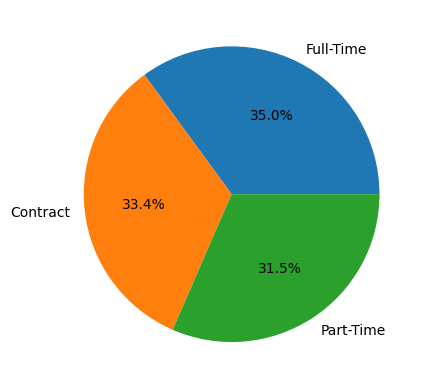

In [14]:
counts = df['EmployeeType'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.show()

## Histrogram Plot

Text(0.5, 1.0, 'Age Distribution')

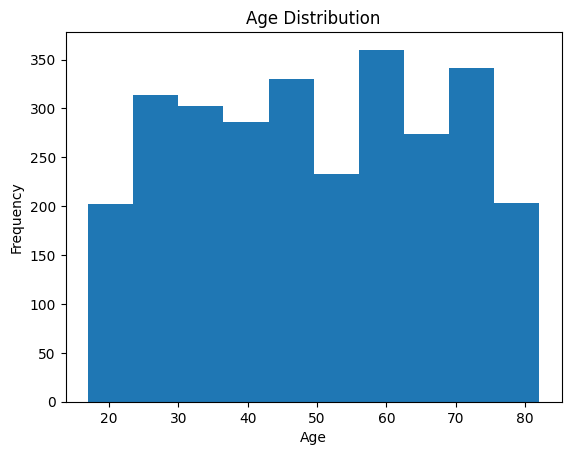

In [21]:
plt.hist(df['Age'],bins=10)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

## BAR PLOT

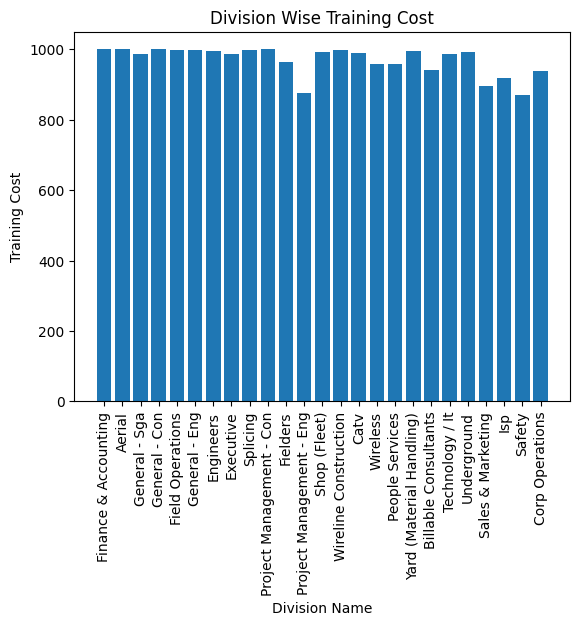

In [31]:
bars=plt.bar(df['Division'],df['Training Cost'])
plt.xlabel("Division Name")
plt.ylabel("Training Cost")
plt.title("Division Wise Training Cost")
plt.xticks(rotation=90)

plt.show()


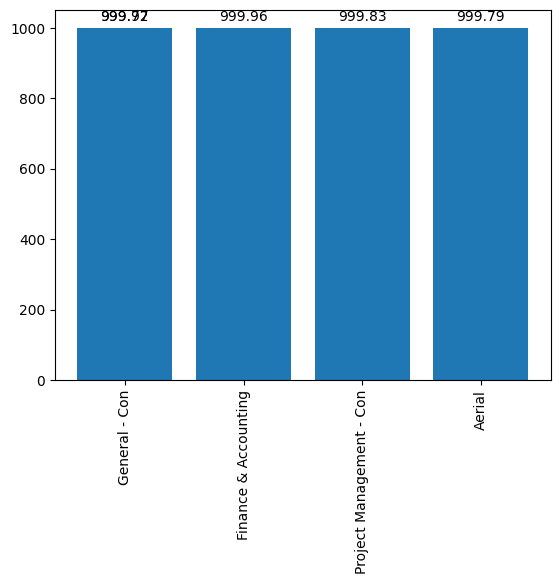

In [30]:
top = df.sort_values('Training Cost', ascending=False).head(5)

bars = plt.bar(top['Division'], top['Training Cost'])
plt.xticks(rotation=90)
plt.bar_label(bars, padding=3)

plt.show()

## Scatter Plot

Text(0.5, 1.0, 'Training Cost VS Engagement Score')

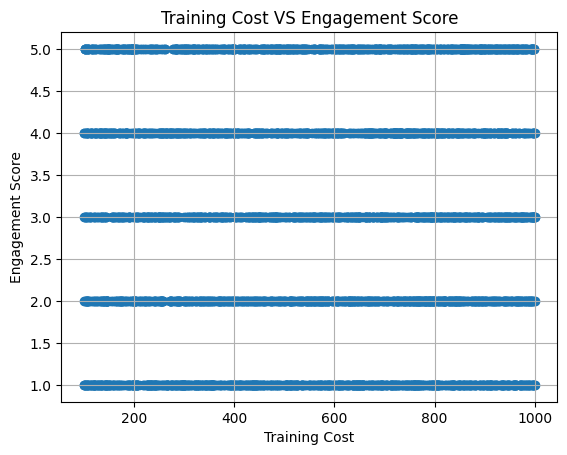

In [35]:
plt.scatter(df['Training Cost'],df['Engagement Score'])
plt.xlabel("Training Cost")
plt.ylabel("Engagement Score")
plt.grid()
plt.title("Training Cost VS Engagement Score")

In [36]:
import seaborn as sns

## jointplot

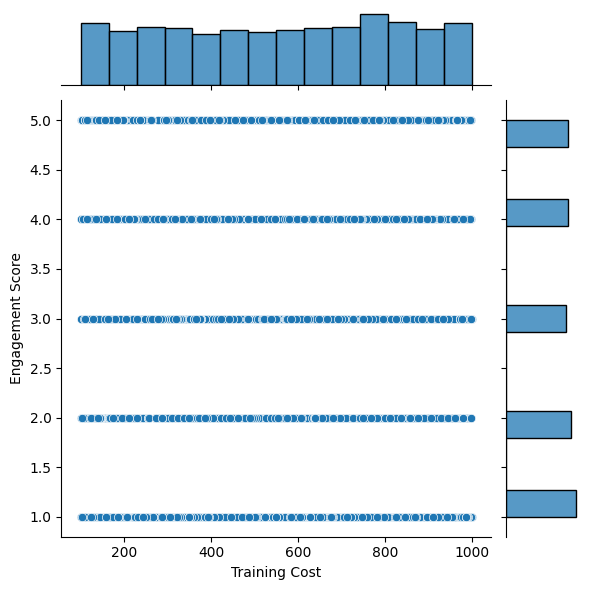

In [37]:
sns.jointplot(x='Training Cost', y='Engagement Score', data=df)

plt.show()

## Violin Plot

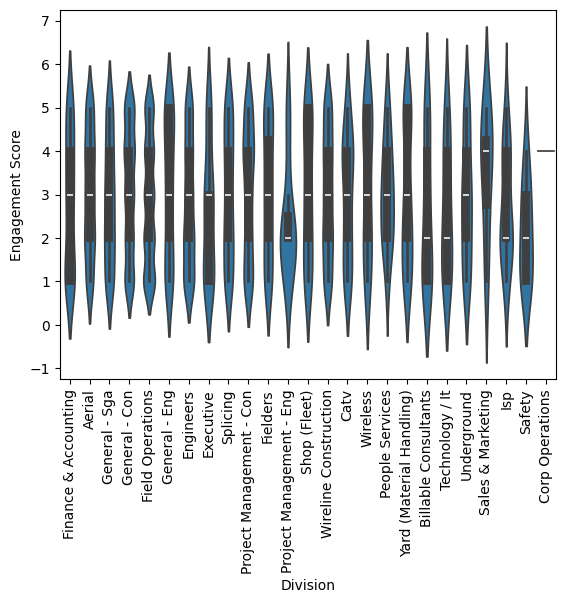

In [39]:
sns.violinplot(x='Division', y='Engagement Score', data=df)

plt.xticks(rotation=90)

plt.show()

## Pair plot

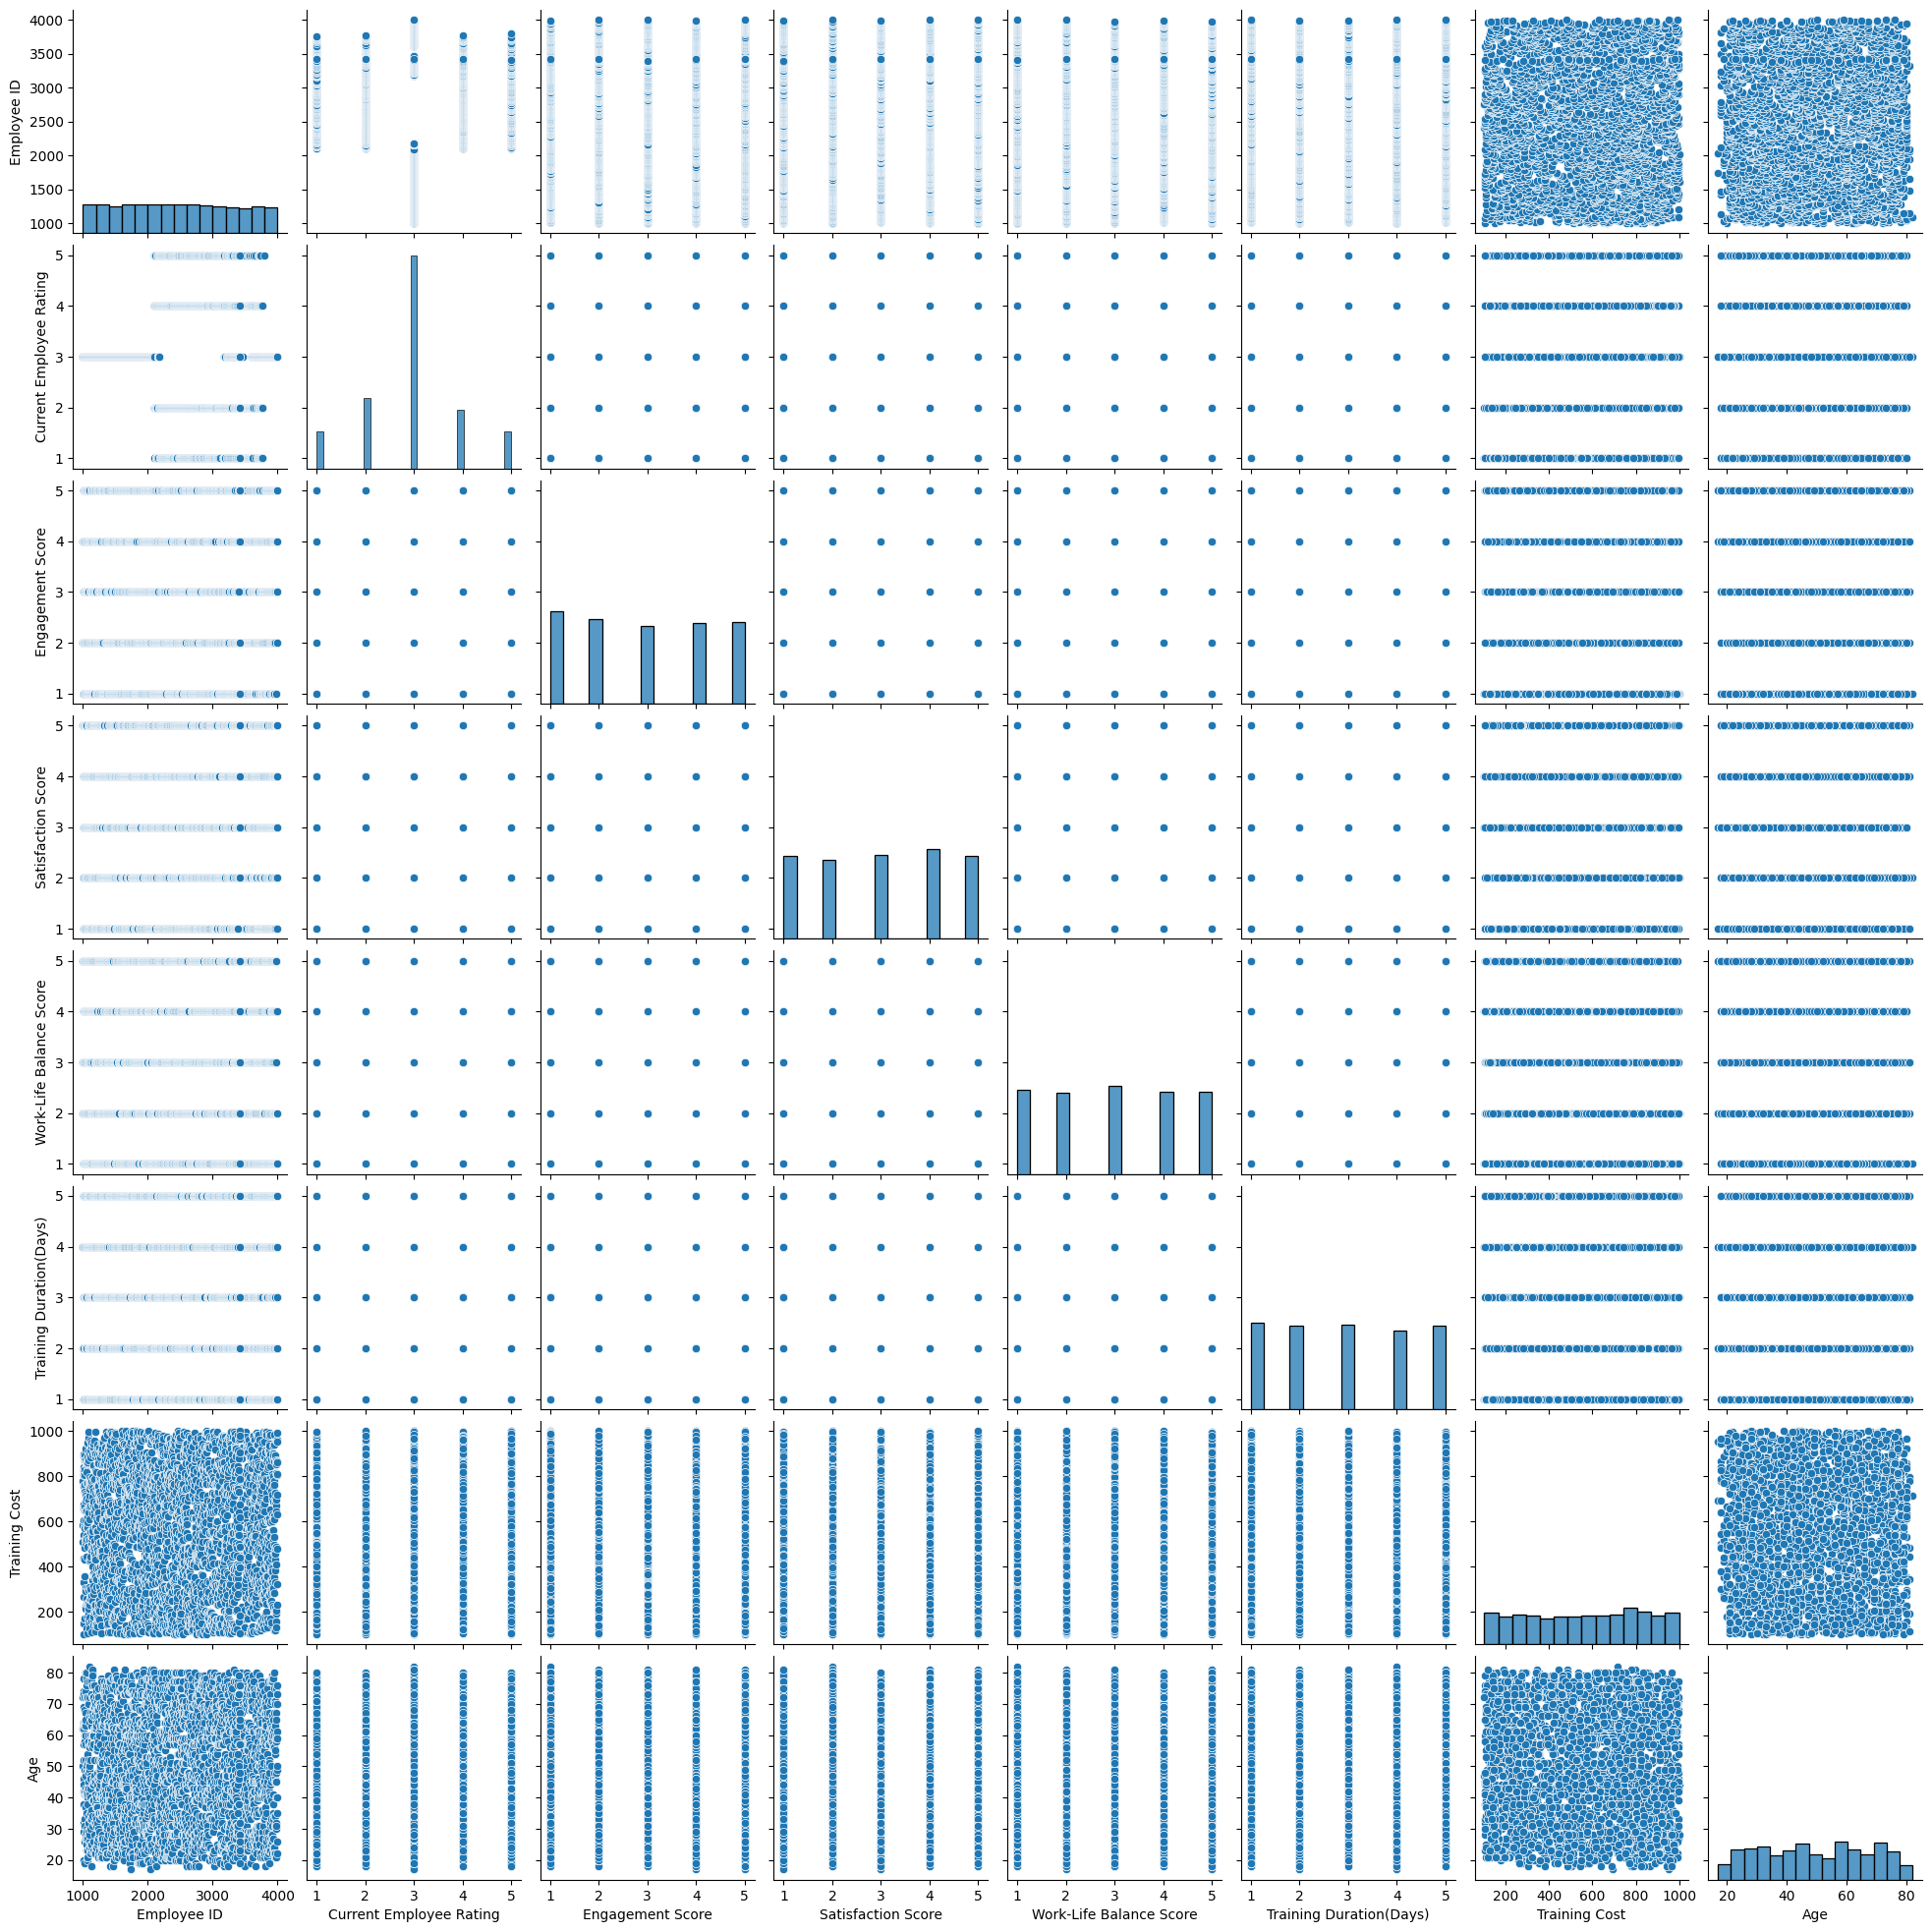

In [41]:
sns.pairplot(df)


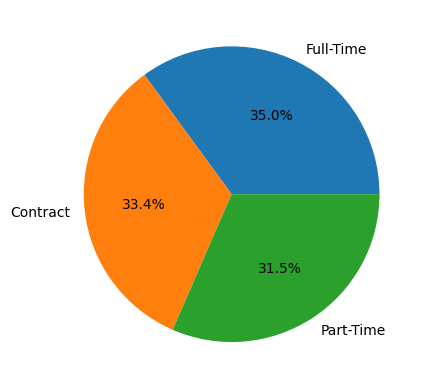

In [50]:
counts = df['EmployeeType'].value_counts()

plt.pie(counts,labels=counts.index, autopct='%1.1f%%')
plt.show()

## BoxPlot

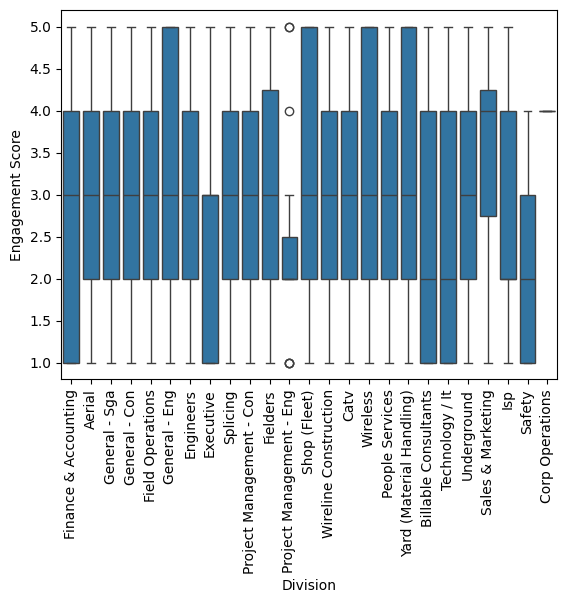

In [55]:
sns.boxplot(x=df['Division'],y=df['Engagement Score'])
plt.xticks(rotation=90)
plt.show()


<Axes: xlabel='EmployeeType', ylabel='Training Cost'>

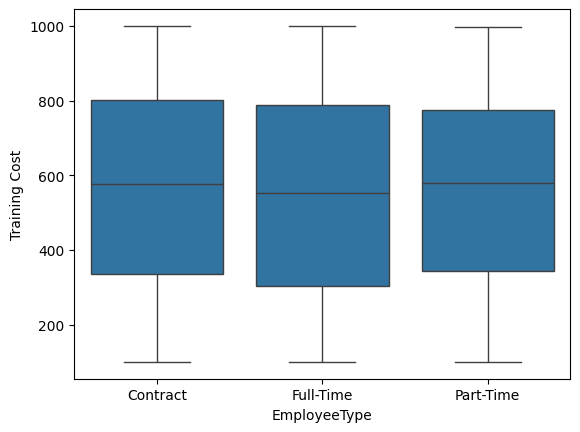

In [62]:
sns.boxplot(x='EmployeeType', y='Training Cost', data=df)

## Count Plot

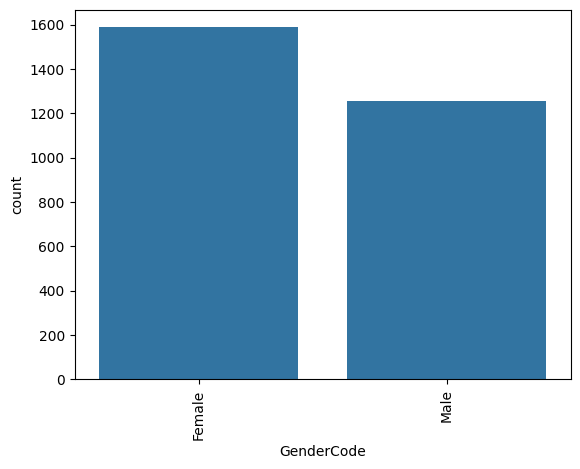

In [60]:
sns.countplot(x='GenderCode',data=df)
plt.xticks(rotation=90)
plt.show()

## Heatmap

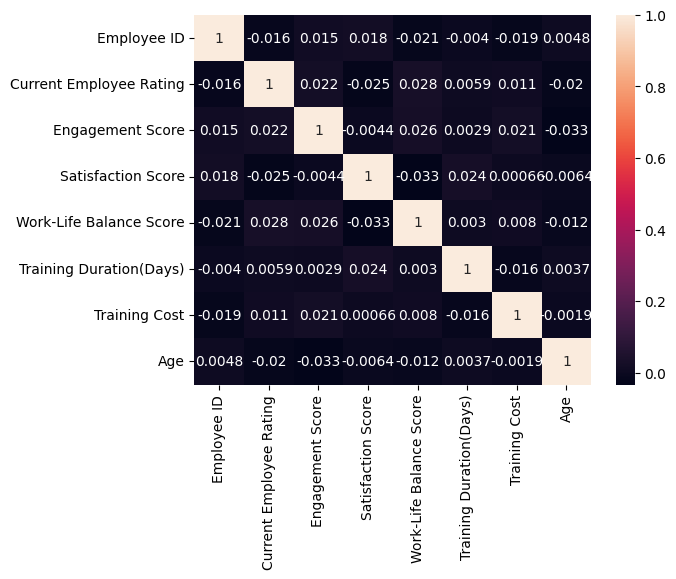

In [58]:
coor=df.corr(numeric_only=True)
sns.heatmap(coor,annot=True)
plt.show()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 [Text(0, 0, 'Finance & Accounting'),
  Text(1, 0, 'Aerial'),
  Text(2, 0, 'General - Sga'),
  Text(3, 0, 'General - Con'),
  Text(4, 0, 'Field Operations'),
  Text(5, 0, 'General - Eng'),
  Text(6, 0, 'Engineers'),
  Text(7, 0, 'Executive'),
  Text(8, 0, 'Splicing'),
  Text(9, 0, 'Project Management - Con'),
  Text(10, 0, 'Fielders'),
  Text(11, 0, 'Project Management - Eng'),
  Text(12, 0, 'Shop (Fleet)'),
  Text(13, 0, 'Wireline Construction'),
  Text(14, 0, 'Catv'),
  Text(15, 0, 'Wireless'),
  Text(16, 0, 'People Services'),
  Text(17, 0, 'Yard (Material Handling)'),
  Text(18, 0, 'Billable Consultants'),
  Text(19, 0, 'Technology / It'),
  Text(20, 0, 'Underground'),
  Text(21, 0, 'Sales & Marketing'),
  Text(22, 0, 'Isp'),
  Text(23, 0, 'Safety'),
  Text(24, 0, 'Corp Operations')])

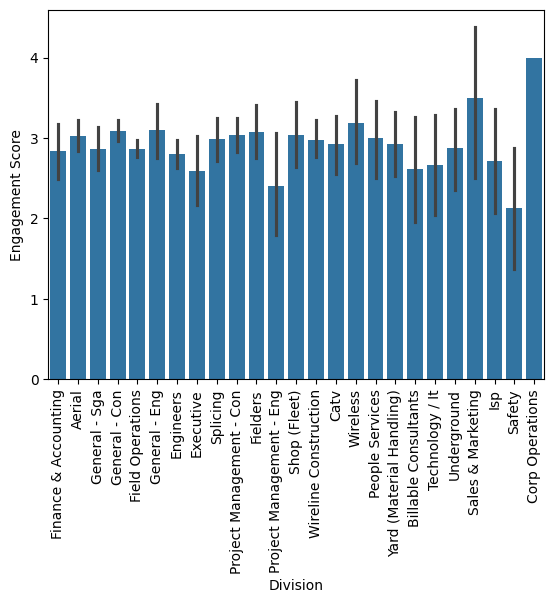

In [71]:
sns.barplot(x='Division', y='Engagement Score', data=df)
plt.xticks(rotation=90)

## Outlier Detection

<Axes: ylabel='Training Cost'>

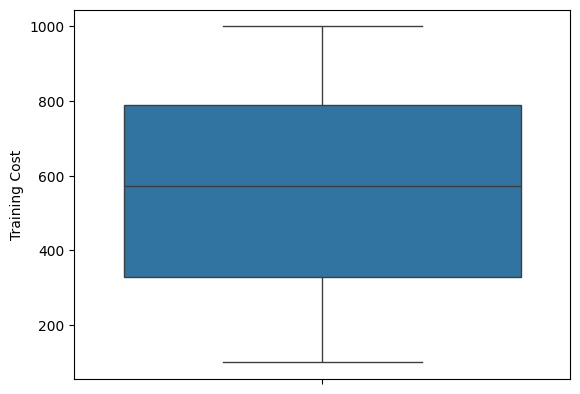

In [72]:
sns.boxplot(df['Training Cost'])

## Correlation Insights

<Axes: >

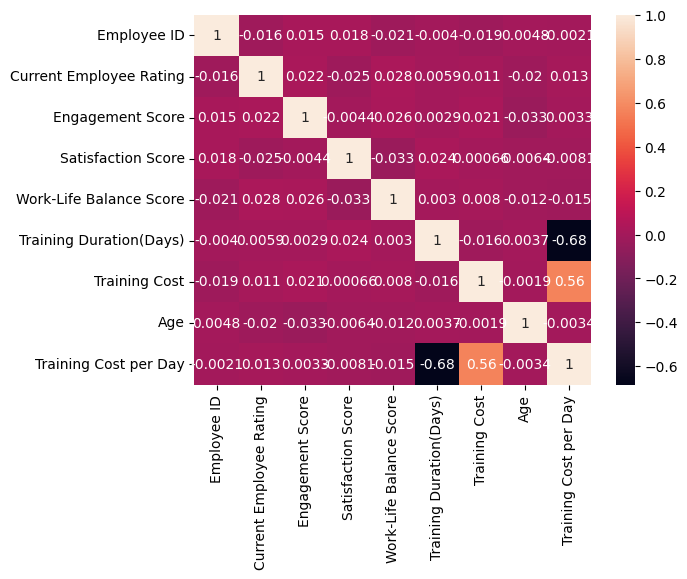

In [73]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

In [8]:
df.head(1)

,Employee ID,StartDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,DepartmentType,Division,...,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Training Cost,Age
0,3427,20-Sep-19,Production Technician I,CCDR,Active,Contract,Zone C,Temporary,Production,Finance & Accounting,...,1,2,3,15-Jul-23,Leadership Development,Internal,Failed,2,606.11,50


In [22]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
le = LabelEncoder()
df['GenderCode_Encoded'] = le.fit_transform(df['GenderCode'])
df['TrainingType_Encoded'] = le.fit_transform(df['Training Type'])
df['EmployeeStatus_Encoded'] = le.fit_transform(df['EmployeeStatus'])
df['TrainingOutcome_Encoded'] = le.fit_transform(df['Training Outcome'])
df['Perf_Target'] = le.fit_transform(df['Performance Score'])


In [14]:
df.head(1)

,Employee ID,StartDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,DepartmentType,Division,...,Training Type,Training Outcome,Training Duration(Days),Training Cost,Age,GenderCode_Encoded,TrainingType_Encoded,EmployeeStatus_Encoded,TrainingOutcome_Encoded,Perf_Target
0,3427,20-Sep-19,Production Technician I,CCDR,Active,Contract,Zone C,Temporary,Production,Finance & Accounting,...,Internal,Failed,2,606.11,50,0,1,0,1,1


In [17]:
x=df[[
    'Engagement Score', 
    'Satisfaction Score', 
    'Work-Life Balance Score', 
    'Age', 
    'Training Duration(Days)', 
    'Training Cost', 
    'Current Employee Rating', 
    'GenderCode', 
    'MaritalDesc'
]]
y=df['EmployeeStatus_Encoded']

In [28]:
X = pd.get_dummies(x, columns=['GenderCode', 'MaritalDesc'], drop_first=True)

In [18]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### LogisticRegression

In [67]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [68]:
y_pred = model.predict(X_test_scaled)

In [69]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [70]:
accuracy1 = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [71]:
print(accuracy1)

0.5131810193321616


### Random Forest 

In [72]:
from sklearn.ensemble import RandomForestClassifier

In [73]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
y_pred = rf_model.predict(X_test_scaled)

In [75]:
accuracy2 = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [76]:
accuracy2

0.8681898066783831

## SVM

In [77]:
from sklearn.svm import SVC

In [78]:
svm_model=SVC(kernel="linear",random_state=42,class_weight="balanced")
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [79]:
y_pred = svm_model.predict(X_test_scaled)

In [80]:
accuracy3 = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [81]:
accuracy3

0.44815465729349735

## Decision Tree:

In [82]:
from sklearn.tree import DecisionTreeClassifier

In [83]:
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [84]:
y_pred = dt_model.predict(X_test_scaled)

In [85]:
accuracy4 = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [86]:
accuracy4

0.7627416520210897

## KNeighborsClassifier

In [87]:
from sklearn.neighbors import KNeighborsClassifier

In [88]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [94]:
y_pred = knn_model.predict(X_test_scaled)

In [95]:
accuracy5 = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [96]:
accuracy5

0.8541300527240774

In [104]:
model_names = ['Logistic', 'Random Forest', 'SVM', 'Decision Tree', 'KNN']
accuracy_values = [accuracy1,accuracy2,accuracy3,accuracy4,accuracy5]

In [102]:
import matplotlib.pyplot as plt

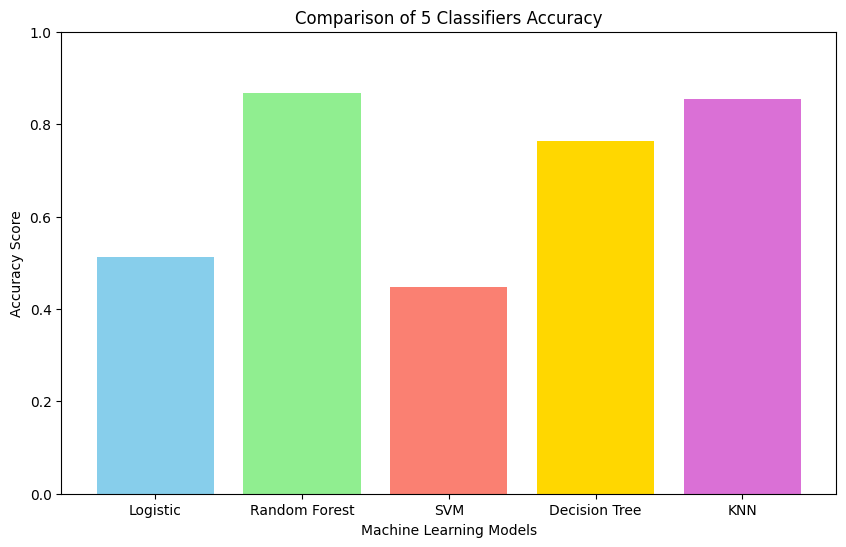

Accuracy Comparison:
Logistic Regression: 0.5131810193321616
Random Forest:       0.8681898066783831
SVM:                 0.44815465729349735
Decision Tree:       0.7627416520210897
KNN:                 0.8541300527240774


In [107]:
plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracy_values, color=['skyblue', 'lightgreen', 'salmon', 'gold', 'orchid'])
plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy Score')
plt.title('Comparison of 5 Classifiers Accuracy')
plt.ylim(0, 1.0) 
plt.show()
print("Accuracy Comparison:")
print("Logistic Regression:", accuracy1)
print("Random Forest:      ", accuracy2)
print("SVM:                ", accuracy3)
print("Decision Tree:      ", accuracy4)
print("KNN:                ", accuracy5)

## Regression Models

In [108]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

In [109]:
selected_features = [
    'Engagement Score', 
    'Satisfaction Score', 
    'Work-Life Balance Score', 
    'Age', 
    'Training Duration(Days)', 
    'Current Employee Rating', 
    'GenderCode', 
    'MaritalDesc'
]
X = df[selected_features]

In [110]:
y = df['Training Cost']

In [111]:
X = df[selected_features]


## Linear Regression


In [117]:
reg1 = LinearRegression()
reg1.fit(X_train_scaled, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [119]:
score1 = r2_score(y_test, reg1.predict(X_test_scaled))
score1

0.0013868778227749123

## RandomForestRegressor

In [120]:
reg2 = RandomForestRegressor(n_estimators=100, random_state=42)
reg2.fit(X_train_scaled, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [122]:
score2 = r2_score(y_test, reg2.predict(X_test_scaled))
score2

-0.08617020475020443

## SVR

In [123]:
reg3 = SVR(kernel='linear')
reg3.fit(X_train_scaled, y_train)


,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [125]:
score3 = r2_score(y_test, reg3.predict(X_test_scaled))
score3

-0.007960803551698481

## DecisionTreeRegressor

In [127]:
reg4 = DecisionTreeRegressor(random_state=42)
reg4.fit(X_train_scaled, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [128]:
score4 = r2_score(y_test, reg4.predict(X_test_scaled))
score4

-1.112585312585312

## KNeighborsRegressor

In [129]:
reg5 = KNeighborsRegressor(n_neighbors=5)
reg5.fit(X_train_scaled, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [131]:
score5 = r2_score(y_test, reg5.predict(X_test_scaled))
score5

-0.16440731640731632

In [133]:
reg_models = ['Linear', 'Random Forest', 'SVR', 'Decision Tree', 'KNN']
r2_scores = [score1, score2, score3, score4, score5]

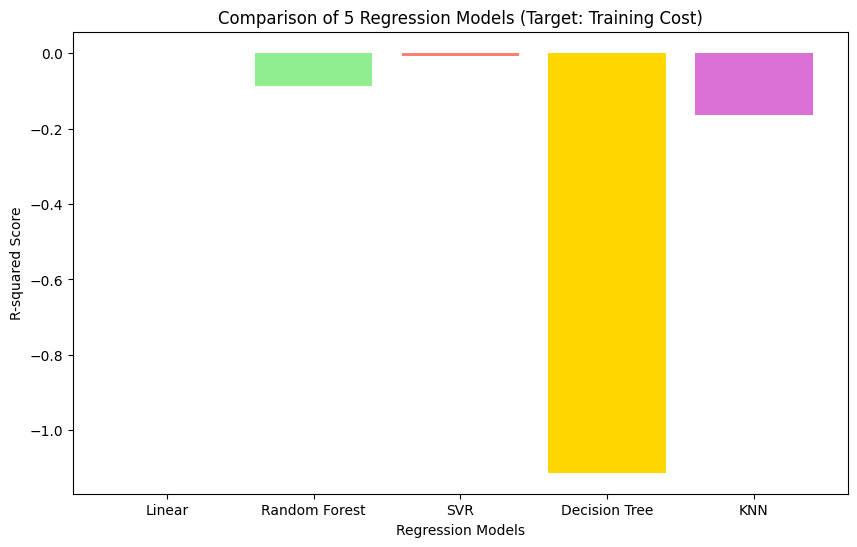

R2 Score Comparison (Higher is better):
Linear Regression:   0.0013868778227749123
Random Forest:       -0.08617020475020443
SVR:                 -0.007960803551698481
Decision Tree:       -1.112585312585312
KNN:                 -0.16440731640731632


In [134]:
plt.figure(figsize=(10, 6))
plt.bar(reg_models, r2_scores, color=['skyblue', 'lightgreen', 'salmon', 'gold', 'orchid'])
plt.xlabel('Regression Models')
plt.ylabel('R-squared Score')
plt.title('Comparison of 5 Regression Models (Target: Training Cost)')
plt.show()

# Display Scores
print("R2 Score Comparison (Higher is better):")
print("Linear Regression:  ", score1)
print("Random Forest:      ", score2)
print("SVR:                ", score3)
print("Decision Tree:      ", score4)
print("KNN:                ", score5)